In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Random Forest Section
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

In [22]:
data = pd.read_csv("C:/Users/micah/Downloads/Kaggle_Projects/playground-series-s5e8/train.csv")

In [23]:
data.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0
9,9,39,management,divorced,tertiary,no,25,yes,no,cellular,8,may,119,1,-1,0,unknown,0


In [24]:
print(data.shape)
print(data.isnull().sum().sum())
#No Null Values in the dataset
data.info()

(750000, 18)
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [25]:
#Dropping or modifying columns that are not useful:
data.drop('id', axis = 1, inplace = True)

Looking at the distributions of all the numberic variables:

In [26]:
data_num = data.select_dtypes(include = ['int64'])
data_cat = data.select_dtypes(include = ['object'])
data_num.head()

,age,balance,day,duration,campaign,pdays,previous,y
0,42,7,25,117,3,-1,0,0
1,38,514,18,185,1,-1,0,0
2,36,602,14,111,2,-1,0,0
3,27,34,28,10,2,-1,0,0
4,26,889,3,902,1,-1,0,1


In [27]:
#obviously y is either 0 or 1
data_num = data_num.drop('y', axis=1)
data_num.head()

,age,balance,day,duration,campaign,pdays,previous
0,42,7,25,117,3,-1,0
1,38,514,18,185,1,-1,0
2,36,602,14,111,2,-1,0
3,27,34,28,10,2,-1,0
4,26,889,3,902,1,-1,0


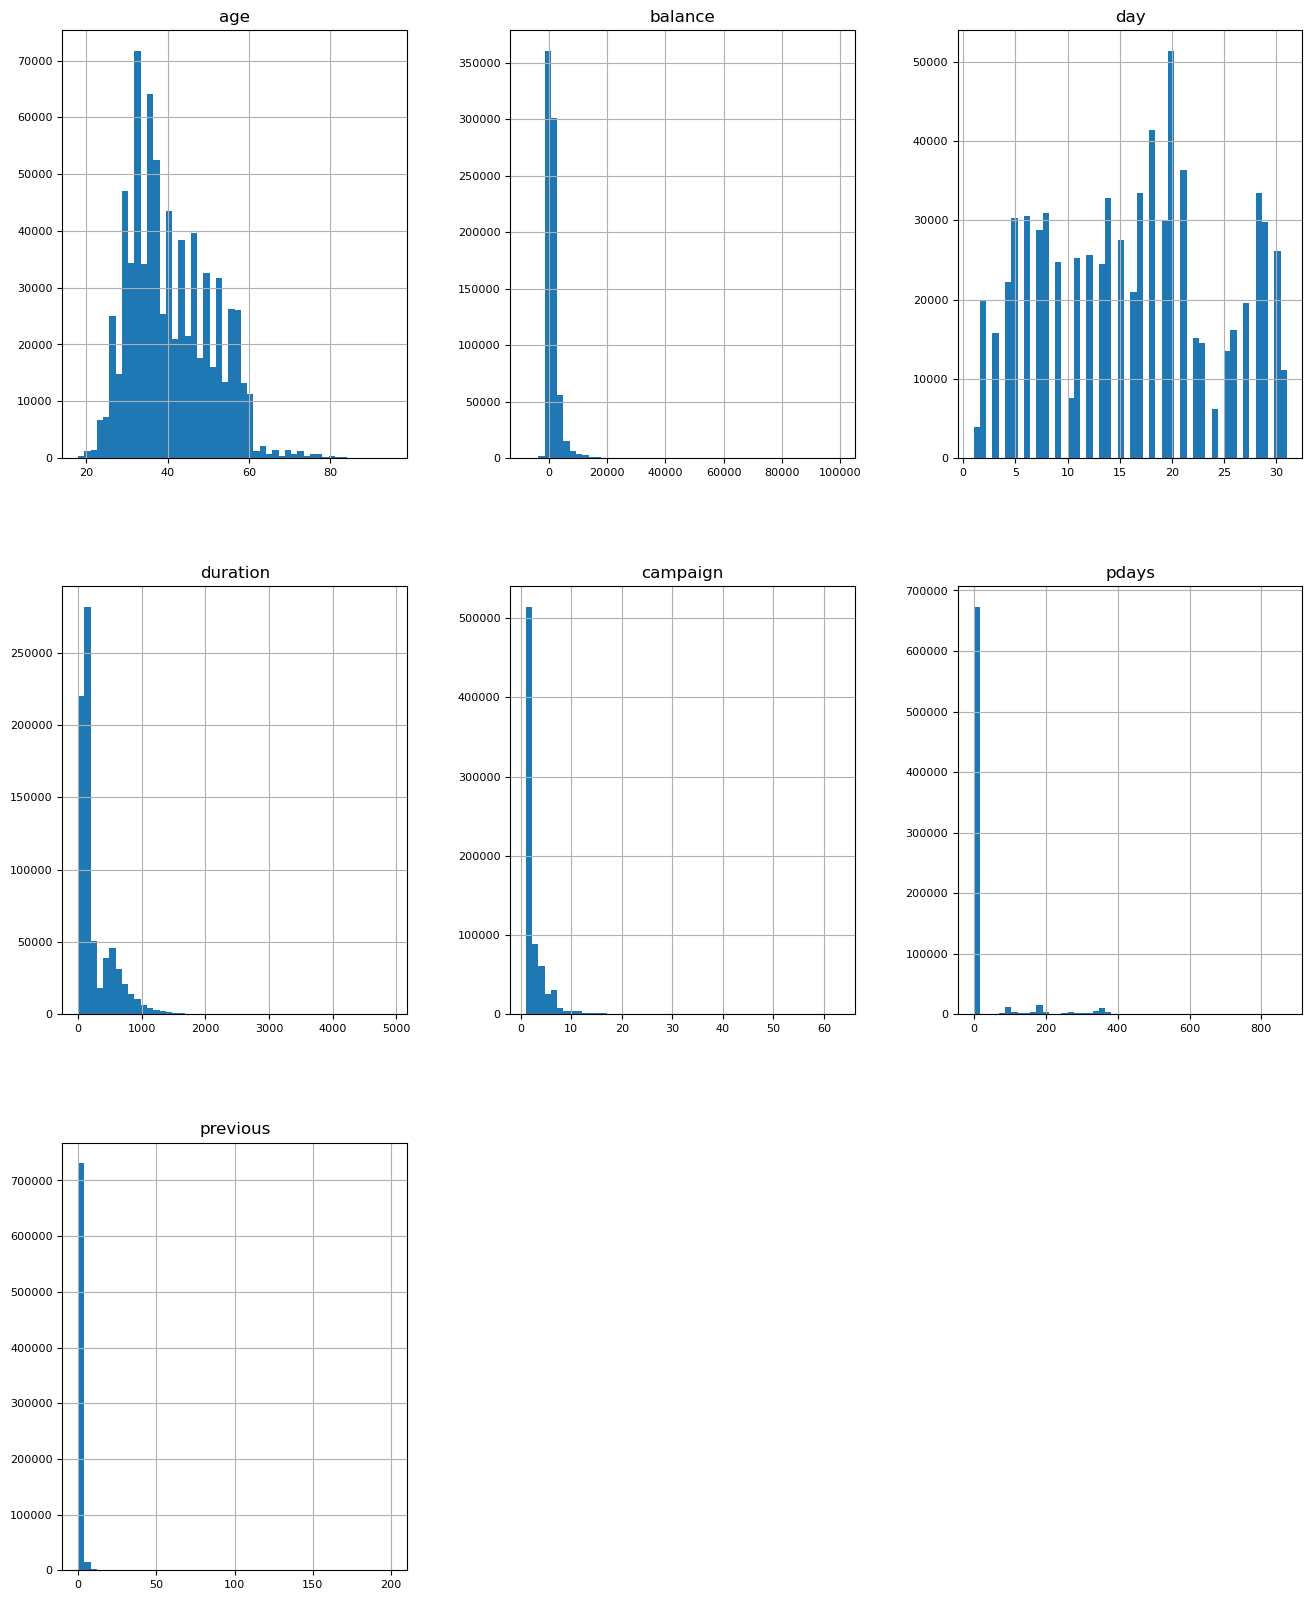

In [28]:
data_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

In [29]:
def plot_pie_charts(df, cols = 5):
    n = len(df.columns)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
    axes = axes.flatten()
    for i, col in enumerate(data_cat):
        data_cat[col].value_counts().plot.pie(
        ax=axes[i],
        autopct='%1.1f%%',
        textprops={'fontsize': 8}
    )
        axes[i].set_title(col)
        axes[i].set_ylabel('')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
    return

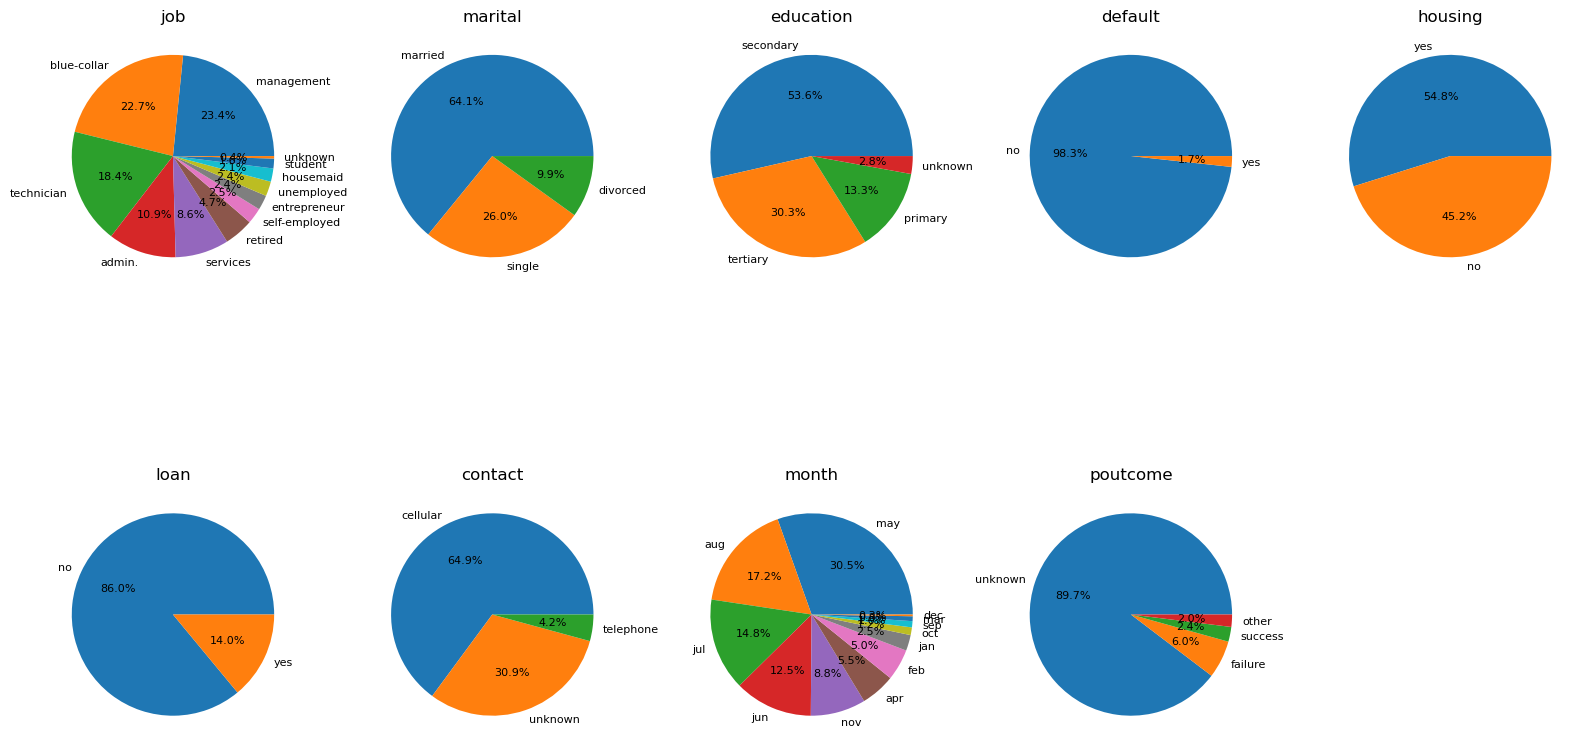

In [30]:
plot_pie_charts(data_cat)

# Random Forest

In [31]:
X = data.drop('y',axis=1)
Y = data[['y']]
X_dum = pd.get_dummies(X) #need numerical variables for model

In [32]:
x_train, x_test, y_train, y_test = train_test_split(X_dum, Y, test_size=.20, random_state = 36)
rf = RandomForestClassifier()

In [33]:
model_rf = rf.fit(x_train,y_train)

C:\Users\micah\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [34]:
preds = model_rf.predict(x_test)

In [35]:
accuracy_score(preds, y_test)

0.9325266666666666

AUC Score: 0.9604


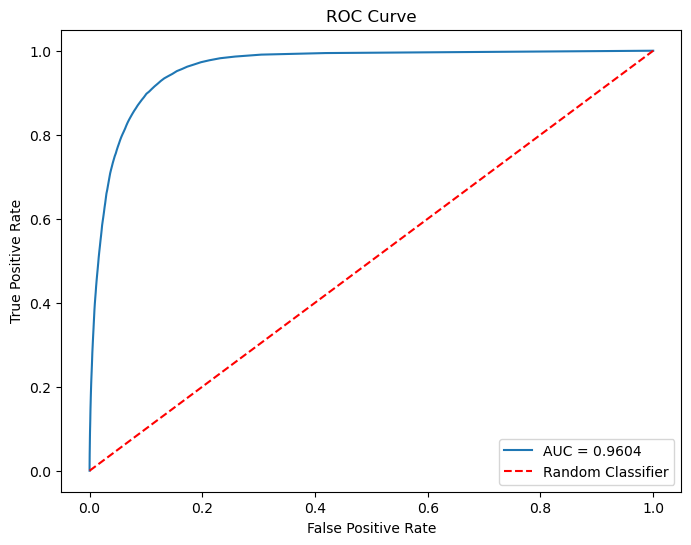

In [37]:
Y_Pred_Proba = model_rf.predict_proba(x_test)[:, 1]
auc_score = roc_auc_score(y_test, Y_Pred_Proba)
print(f"AUC Score: {auc_score:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, Y_Pred_Proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show();